In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/datasets/drjohnholash/demo-knes381/subject_1321.csv', skiprows=[1,2,3])
df.head()

,TIME,VO2,VO2/kg,METS,VCO2,VE,RER,RR,Vt,FEO2,FECO2,HR,VE/,VE/.1,PetCO2,Power,Lactate
0,0.548500,0.286087,4.498218,1.285205,0.207759,10.016462,0.726212,16.408386,0.610448,17.150507,2.951995,74.0,35.011990,48.211826,19.651297,NaN,NaN
1,1.048500,0.323012,5.078805,1.451087,0.232768,11.156643,0.720616,18.000000,0.619814,17.103550,2.969106,76.0,34.539406,47.930397,19.818874,NaN,NaN
2,1.532667,0.294654,4.632925,1.323693,0.217481,10.376404,0.738090,18.588640,0.558212,17.162443,2.982493,74.0,35.215557,47.711712,19.880138,NaN,NaN
3,2.026167,0.282529,4.442279,1.269222,0.206691,10.325383,0.731574,18.237082,0.566175,17.304867,2.850333,74.0,36.546284,49.955666,18.997364,50.0,NaN
4,2.511500,0.490318,7.709397,2.202685,0.358941,16.674282,0.732058,24.725275,0.674382,17.033770,3.062165,86.0,34.007103,46.454113,20.526415,50.0,NaN


In [3]:
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['TIME', 'VO2', 'VCO2', 'VE', 'FECO2']).reset_index(drop=True)
df.head()

,TIME,VO2,VO2/kg,METS,VCO2,VE,RER,RR,Vt,FEO2,FECO2,HR,VE/,VE/.1,PetCO2,Power,Lactate
0,0.548500,0.286087,4.498218,1.285205,0.207759,10.016462,0.726212,16.408386,0.610448,17.150507,2.951995,74.0,35.011990,48.211826,19.651297,NaN,NaN
1,1.048500,0.323012,5.078805,1.451087,0.232768,11.156643,0.720616,18.000000,0.619814,17.103550,2.969106,76.0,34.539406,47.930397,19.818874,NaN,NaN
2,1.532667,0.294654,4.632925,1.323693,0.217481,10.376404,0.738090,18.588640,0.558212,17.162443,2.982493,74.0,35.215557,47.711712,19.880138,NaN,NaN
3,2.026167,0.282529,4.442279,1.269222,0.206691,10.325383,0.731574,18.237082,0.566175,17.304867,2.850333,74.0,36.546284,49.955666,18.997364,50.0,NaN
4,2.511500,0.490318,7.709397,2.202685,0.358941,16.674282,0.732058,24.725275,0.674382,17.033770,3.062165,86.0,34.007103,46.454113,20.526415,50.0,NaN


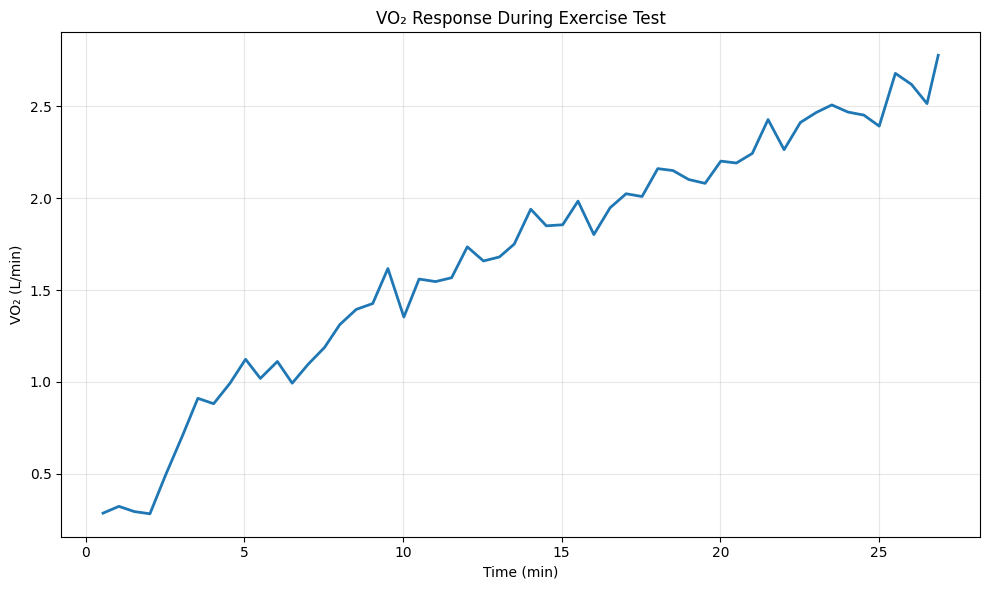

In [4]:
plt.figure(figsize=(10,6))
plt.plot(df['TIME'], df['VO2'], linewidth=2)

plt.xlabel('Time (min)')
plt.ylabel('VO₂ (L/min)')
plt.title('VO₂ Response During Exercise Test')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

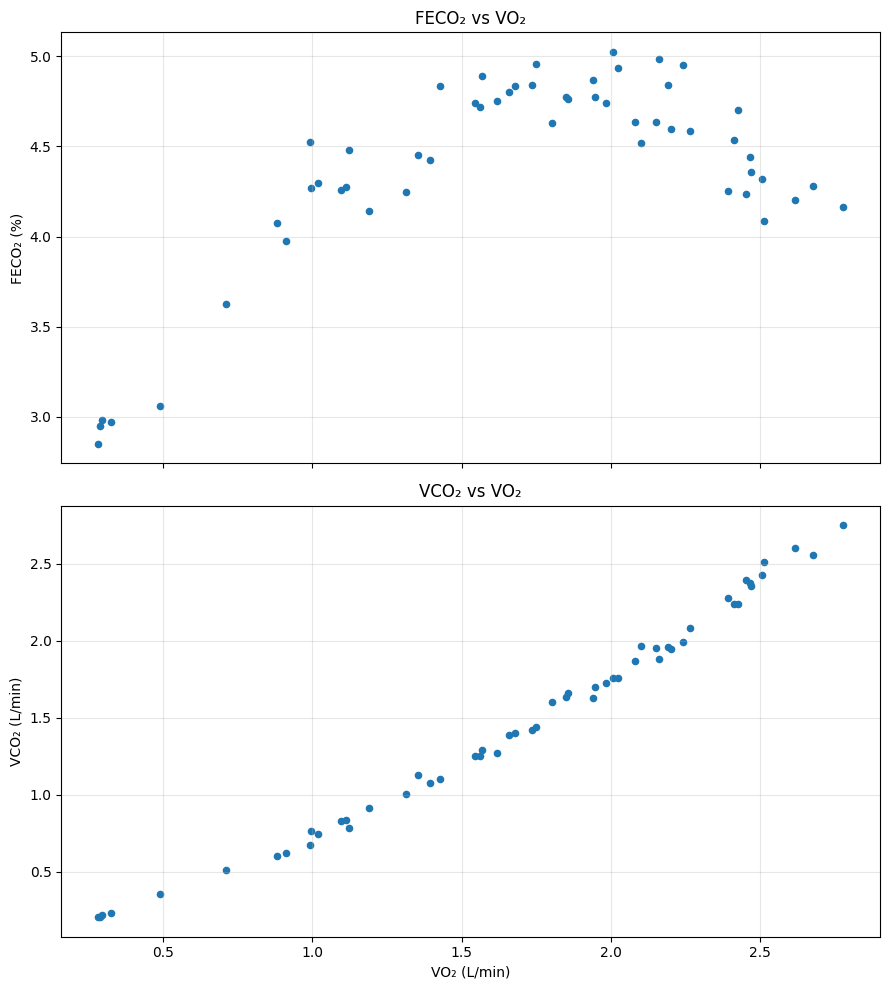

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(9, 10), sharex=True)

# FECO2 vs VO2
axes[0].scatter(df['VO2'], df['FECO2'], s=20)
axes[0].set_ylabel('FECO₂ (%)')
axes[0].set_title('FECO₂ vs VO₂')
axes[0].grid(True, alpha=0.3)

# VCO2 vs VO2
axes[1].scatter(df['VO2'], df['VCO2'], s=20)
axes[1].set_xlabel('VO₂ (L/min)')
axes[1].set_ylabel('VCO₂ (L/min)')
axes[1].set_title('VCO₂ vs VO₂')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
df['VE_VO2'] = df['VE'] / df['VO2']
df['VE_VCO2'] = df['VE'] / df['VCO2']

In [7]:
# GET = where VE/VO2 starts increasing
get_index = df['VE_VO2'].idxmin()

# RCP = where VE/VCO2 starts increasing
rcp_index = df['VE_VCO2'].idxmin()

get_time = df.loc[get_index, 'TIME']
rcp_time = df.loc[rcp_index, 'TIME']

print("GET at time:", get_time)
print("RCP at time:", rcp_time)

GET at time: 4.5465
RCP at time: 17.53084


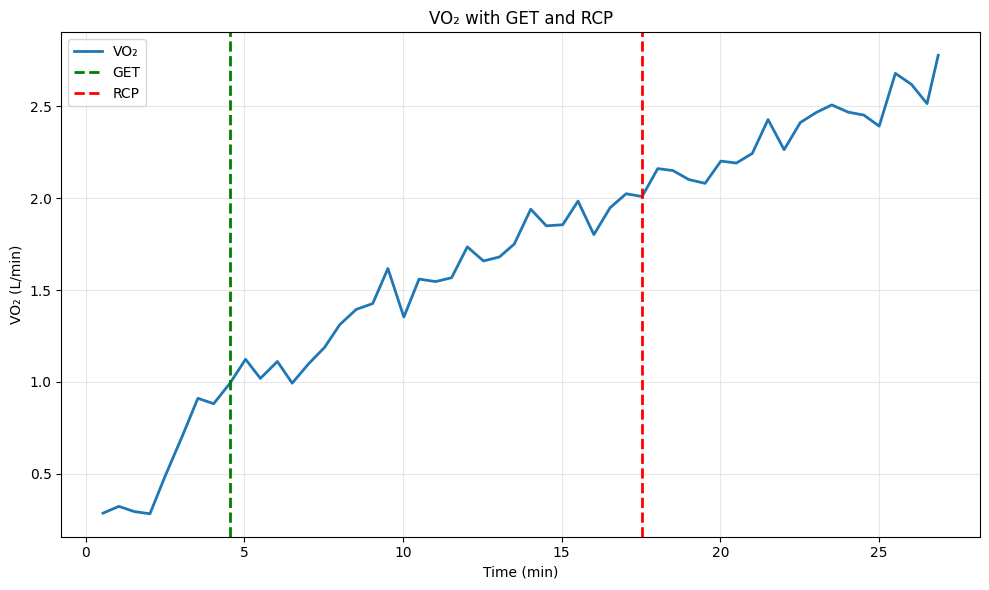

In [8]:
plt.figure(figsize=(10,6))

plt.plot(df['TIME'], df['VO2'], label='VO₂', linewidth=2)
plt.axvline(get_time, color='green', linestyle='--', linewidth=2, label='GET')
plt.axvline(rcp_time, color='red', linestyle='--', linewidth=2, label='RCP')

plt.xlabel('Time (min)')
plt.ylabel('VO₂ (L/min)')
plt.title('VO₂ with GET and RCP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()